In [1]:
!pip install --upgrade pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 65.4 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.2.1
    Uninstalling pillow-11.2.1:
      Successfully uninstalled pillow-11.2.1


# restart

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

import copy

In [2]:
from google.colab import files
uploaded = files.upload()  # style.jpg & content.jpg


Saving content.jpg to content.jpg
Saving style.jpg to style.jpg


In [11]:

def load_image(filename, max_size=512):
    image = Image.open(filename).convert('RGB')
    size = min(max(image.size), max_size)

    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x[:3, :, :]),
        transforms.Normalize((0.485, 0.456, 0.406),
                             (0.229, 0.224, 0.225))
    ])
    image = transform(image).unsqueeze(0)
    return image.to(torch.float)

content = load_image("content.jpg")
style = load_image("style.jpg")


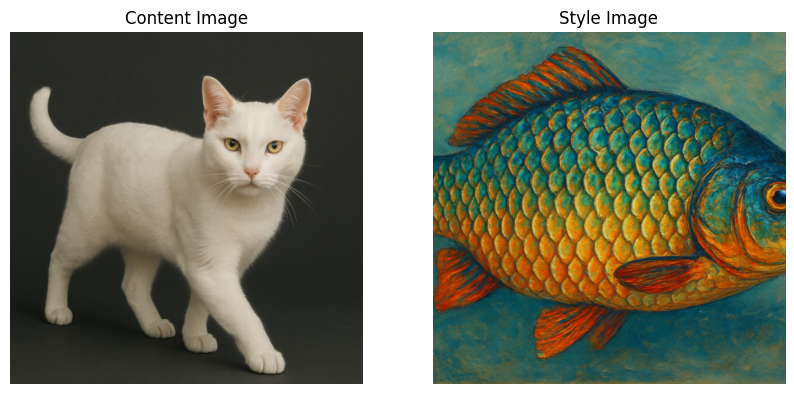

In [12]:
def imshow(tensor, title=None):
    image = tensor.clone().detach().squeeze(0)
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + \
            torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    image = image.clamp(0, 1)
    plt.imshow(image.permute(1, 2, 0))
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
imshow(content, title="Content Image")
plt.subplot(1,2,2)
imshow(style, title="Style Image")
plt.show()


In [13]:
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

def gram_matrix(input):
    a, b, c, d = input.size()
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t())
    return G.div(a * b * c * d)

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input


In [14]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.eval()

# Normalizasyon için gerekli parametreler
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])

# Normalizasyon katmanı
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = mean.clone().view(-1, 1, 1)
        self.std = std.clone().view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std

# Stil ve içerik loss'larının ekleneceği katmanlar
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, norm_mean, norm_std,
                                style_img, content_img):
    cnn = copy.deepcopy(cnn)
    norm = Normalization(norm_mean, norm_std)

    content_losses = []
    style_losses = []

    model = nn.Sequential(norm)
    i = 0

    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{i}'
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)


    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break
    model = model[:i+1]

    return model, style_losses, content_losses


Step 50 | Style Loss: 0.1033 | Content Loss: 295.0750
Step 100 | Style Loss: 0.0306 | Content Loss: 263.9035
Step 150 | Style Loss: 0.0246 | Content Loss: 251.4467
Step 200 | Style Loss: 0.0237 | Content Loss: 244.7411
Step 250 | Style Loss: 0.0235 | Content Loss: 241.2385
Step 300 | Style Loss: 0.0236 | Content Loss: 239.1680
Step 350 | Style Loss: 0.0236 | Content Loss: 237.9942
Step 400 | Style Loss: 0.0236 | Content Loss: 237.1624
Step 450 | Style Loss: 0.0236 | Content Loss: 236.5870
Step 500 | Style Loss: 0.0236 | Content Loss: 236.1458


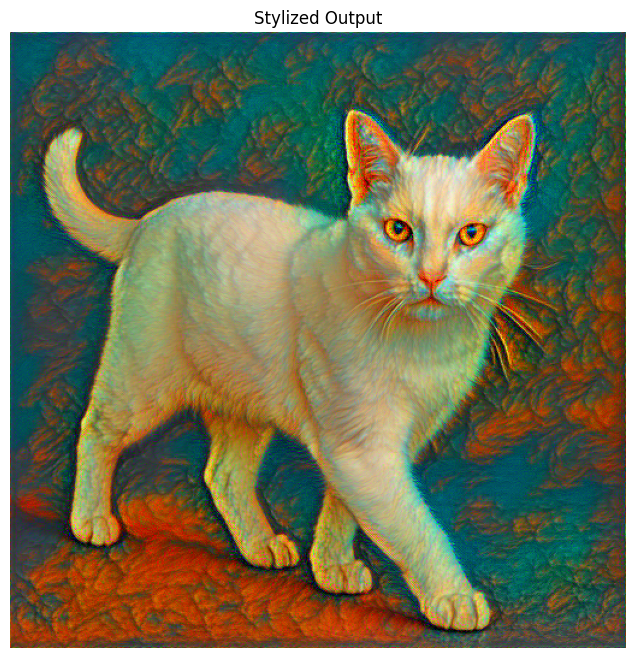

In [16]:
input_img = content.clone()
optimizer = optim.LBFGS([input_img.requires_grad_()])

model, style_losses, content_losses = get_style_model_and_losses(
    cnn, cnn_normalization_mean, cnn_normalization_std, style, content)

num_steps = 500
style_weight = 1e6
content_weight = 1000

run = [0]
while run[0] <= num_steps:
    def closure():
        optimizer.zero_grad()
        model(input_img)
        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        loss = style_score * style_weight + content_score * content_weight
        loss.backward()
        run[0] += 1

        if run[0] % 50 == 0:
            print(f"Step {run[0]} | Style Loss: { style_score:.4f} | Content Loss: {content_score:.4f}")

        return loss
    optimizer.step(closure)


plt.figure(figsize=(8, 8))
imshow(input_img, title="Stylized Output")
plt.show()


In [17]:
def save_image(tensor, path):
    image = tensor.clone().detach().squeeze(0)
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + \
            torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    image = image.clamp(0, 1)
    image = transforms.ToPILImage()(image)
    image.save(path)

save_image(input_img, "stylized_output.jpg")
print("Görsel kaydedildi: stylized_output.jpg")


Görsel kaydedildi: stylized_output.jpg


In [18]:
from google.colab import files
files.download("stylized_output.jpg")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>